In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import constants
from scipy.optimize import minimize_scalar

In [3]:
from ipywidgets import IntProgress         # progress bar
from IPython.display import display
import time

Physical constants

In [4]:
PHI0 = constants.h / (2 * constants.e)          # Flux quantum [Wb]
EPS0 = constants.epsilon_0                      # Vacuum permittivity [F/m]

# Device / chain parameters   
https://arxiv.org/pdf/1806.06093

https://arxiv.org/pdf/2408.06154

----- SNAIL topology -----

One small junction in parallel with a series array of 3 large junctions

In [12]:
N_LARGE_JJ = 3

----- Junction geometry (representative "large SNAIL" values) -----

In [13]:
big_jj_width  = 2.4e-6                          # [m]
big_jj_length = 2.4e-6                          # [m]

small_jj_width  = 0.35e-6                       # [m]
small_jj_length = 1.0e-6                        # [m]

----- Junction technology -----

In [14]:
Jc = 4.0e6                                      # Critical current density [A/m^2]
eps_r = 11.0                                    # Relative permittivity of AlOx
oxide_thickness = 2.0e-9                        # Tunnel barrier thickness [m]

----- Chain parameters -----

In [30]:
N_cells = 912                                   # Number of SNAIL cells in the chain
Z_port = 50.0                                   # Port impedance [Ohm]

# One unit cell = series SNAIL element + shunt-to-ground capacitance

C_ground_per_cell = 80e-15                     # [F]
#C_ground_per_cell = 250e-15                    # [F]
L_geometric_per_cell = 0e-12                # Optional extra geometric series inductance [H]

----- Sweep ranges -----

In [31]:
flux_points = 1001
freq_points = 5001

flux_frustration = np.linspace(-1.5, 1.5, flux_points)   # Phi_ext / Phi0
phi_ext_array = 2.0 * np.pi * flux_frustration          # External flux phase [rad]

freq_array = np.linspace(4e9, 8e9, freq_points)        # [Hz]
omega_array = 2.0 * np.pi * freq_array                 # [rad/s]

# 3. Junction parameters derived from geometry

In [32]:
#A_big = big_jj_width * big_jj_length
#A_small = small_jj_width * small_jj_length

#Ic_big = Jc * A_big
#Ic_small = Jc * A_small

alpha = 0.12

Ic_big = 1.5e-6
Ic_small = alpha*Ic_big

EJ_big = PHI0 * Ic_big / (2.0 * np.pi)          # [J]
EJ_small = PHI0 * Ic_small / (2.0 * np.pi)      # [J]

#alpha = EJ_small / EJ_big                       # SNAIL asymmetry parameter

#C_big = EPS0 * eps_r * A_big / oxide_thickness
#C_small = EPS0 * eps_r * A_small / oxide_thickness
C_big = 80e-15
C_small = alpha*C_big

# Linear Josephson inductance corresponding to one large junction
LJ_big = (PHI0 / (2.0 * np.pi))**2 / EJ_big


print("=== Representative SNAIL parameters ===")
print(f"alpha = EJ_small / EJ_big = {alpha:.4f}")
print(f"Ic_big   = {Ic_big*1e6:.3f} uA")
print(f"Ic_small = {Ic_small*1e6:.3f} uA")
print(f"C_big    = {C_big*1e15:.3f} fF")
print(f"C_small  = {C_small*1e15:.3f} fF")
print(f"LJ_big   = {LJ_big*1e12:.3f} pH")

=== Representative SNAIL parameters ===
alpha = EJ_small / EJ_big = 0.1200
Ic_big   = 1.500 uA
Ic_small = 0.180 uA
C_big    = 80.000 fF
C_small  = 9.600 fF
LJ_big   = 219.404 pH


# SNAIL potential and flux-dependent minimum

Standart SNAIL (3+1 JJ) - reduce the problem to one phase variable

# Potential energy

$U(\varphi_s,\Phi_{ext})/E_J = 3+\alpha - \alpha\cos(\varphi_s) -3\cos(\frac{\phi_{ext}-\varphi_s}{3})$, 

$\phi_{ext}=2\pi\frac{\Phi_{ext}}{\Phi_0}$

In [33]:
def snail_potential(phi_small, phi_ext, alpha, n_large=3):
    return ( -alpha * np.cos(phi_small) - n_large * np.cos((phi_ext - phi_small) / n_large))

def track_snail_minimum(phi_ext_array, alpha, n_large=3):
    """
    Follow the SAME continuous minimum branch as external flux changes.

    This is important: a naive minimization in [-pi, pi] breaks the branch
    after ~0.5 Phi0. The continuation below lets the minimum shift by 2*pi
    when needed, so the branch stays physically continuous over many flux quanta.
    """
    phi_min_array = np.zeros_like(phi_ext_array, dtype=float)

    # Wide search for the first flux point
    phi_grid = np.linspace(-4.0 * np.pi, 4.0 * np.pi, 20001)
    U_grid = snail_potential(phi_grid, phi_ext_array[0], alpha, n_large=n_large)
    phi_min_array[0] = phi_grid[np.argmin(U_grid)]

    # Continue the branch point by point
    for k in range(1, len(phi_ext_array)):
        phi_prev = phi_min_array[k - 1]
        candidates = []

        # Search near the previous minimum and also in neighboring 2*pi-shifted branches
        for shift in (-2.0 * np.pi, 0.0, 2.0 * np.pi):
            left = phi_prev + shift - 1.2 * np.pi
            right = phi_prev + shift + 1.2 * np.pi

            res = minimize_scalar(
                lambda x: snail_potential(x, phi_ext_array[k], alpha, n_large=n_large),
                bounds=(left, right),
                method="bounded",
            )
            candidates.append((res.fun, res.x))

        # Pick the best local minimum
        phi_min_array[k] = min(candidates, key=lambda item: item[0])[1]

    return phi_min_array


phi_small_min = track_snail_minimum(phi_ext_array, alpha, n_large=N_LARGE_JJ)
phi_large_min = (phi_ext_array - phi_small_min) / N_LARGE_JJ

# 5. Effective linearized SNAIL parameters

Curvature of the SNAIL potential with respect to the port phase

For a 1-small + 3-large JJ SNAIL:

  $u_2(\phi_{ext}) = \alpha \cos(\phi_{small-min}) + \frac{1}{3} \cos(\phi_{large-min})$

Then: $L_{eff} = L_{J-big}/u_2$


In [34]:
u2 = alpha * np.cos(phi_small_min) + (1.0 / N_LARGE_JJ) * np.cos(phi_large_min)

if np.any(u2 <= 0):
    raise RuntimeError(
    )

L_snail_eff = LJ_big / u2

# Effective small-signal capacitance of the SNAIL as a two-terminal element:
# small branch capacitance in parallel with the equivalent capacitance
# of 3 large junctions in series.

C_snail_eff = C_small + C_big / N_LARGE_JJ

# Optional total series inductance per cell
L_series_total = L_snail_eff + L_geometric_per_cell

# Plasma frequency of one linearized SNAIL cell
plasma_frequency = 1.0 / (2.0 * np.pi * np.sqrt(L_series_total * C_snail_eff))

print("\n=== Effective linearized cell parameters ===")
print(f"C_snail_eff = {C_snail_eff*1e15:.3f} fF")
print(f"L_eff(min)  = {np.min(L_snail_eff)*1e12:.3f} pH")
print(f"L_eff(max)  = {np.max(L_snail_eff)*1e12:.3f} pH")
print(f"f_plasma(min) = {np.min(plasma_frequency)/1e9:.3f} GHz")
print(f"f_plasma(max) = {np.max(plasma_frequency)/1e9:.3f} GHz")


=== Effective linearized cell parameters ===
C_snail_eff = 36.267 fF
L_eff(min)  = 483.979 pH
L_eff(max)  = 1028.456 pH
f_plasma(min) = 26.060 GHz
f_plasma(max) = 37.989 GHz


# Frequency-dependent SNAIL series impedance

A Josephson element linearized around a minimum behaves like
an inductor in parallel with its capacitance:

$Z_{JJ}(\omega) = i \omega L / (1 - \omega^2 L C)$

Then we add a small geometric series inductance per cell.

In [35]:
omega_2d = omega_array[:, None]

Z_snail = (
    1j * omega_2d * L_snail_eff[None, :]
    / (1.0 - (omega_2d**2) * L_snail_eff[None, :] * C_snail_eff)
)

Z_series = Z_snail + 1j * omega_2d * L_geometric_per_cell

# Shunt-to-ground admittance of each cell island
Y_shunt = 1j * omega_2d * C_ground_per_cell

# ABCD matrix of one symmetric unit cell

A symmetric cell is modeled as:

shunt(Y/2) -> series(Z) -> shunt(Y/2)

This is better behaved than an asymmetric choice.

The ABCD matrix is:
A = D = 1 + ZY/2
B = Z
C = Y * (1 + ZY/4)

In [36]:
A_cell = 1.0 + 0.5 * Z_series * Y_shunt
B_cell = Z_series
C_cell = Y_shunt * (1.0 + 0.25 * Z_series * Y_shunt)
D_cell = A_cell.copy()

# ABCD matrix of the full chain of N identical cells

In [37]:
A_tot = np.ones_like(A_cell, dtype=complex)
B_tot = np.zeros_like(B_cell, dtype=complex)
C_tot = np.zeros_like(C_cell, dtype=complex)
D_tot = np.ones_like(D_cell, dtype=complex)

for _ in range(N_cells):
    A_new = A_tot * A_cell + B_tot * C_cell
    B_new = A_tot * B_cell + B_tot * D_cell
    C_new = C_tot * A_cell + D_tot * C_cell
    D_new = C_tot * B_cell + D_tot * D_cell

    A_tot, B_tot, C_tot, D_tot = A_new, B_new, C_new, D_new

# Convert ABCD to S21 for equal source/load impedances

For a 2-port network with equal reference impedances $Z_0$:

$S_{21} = 2 / (A + B/Z_0 + C*Z_0 + D)$

In [38]:
S21 = 2.0 / (A_tot + B_tot / Z_port + C_tot * Z_port + D_tot)

# Correct dB conversion for an amplitude transmission coefficient
S21_dB = 20.0 * np.log10(np.abs(S21))

# Test Plots

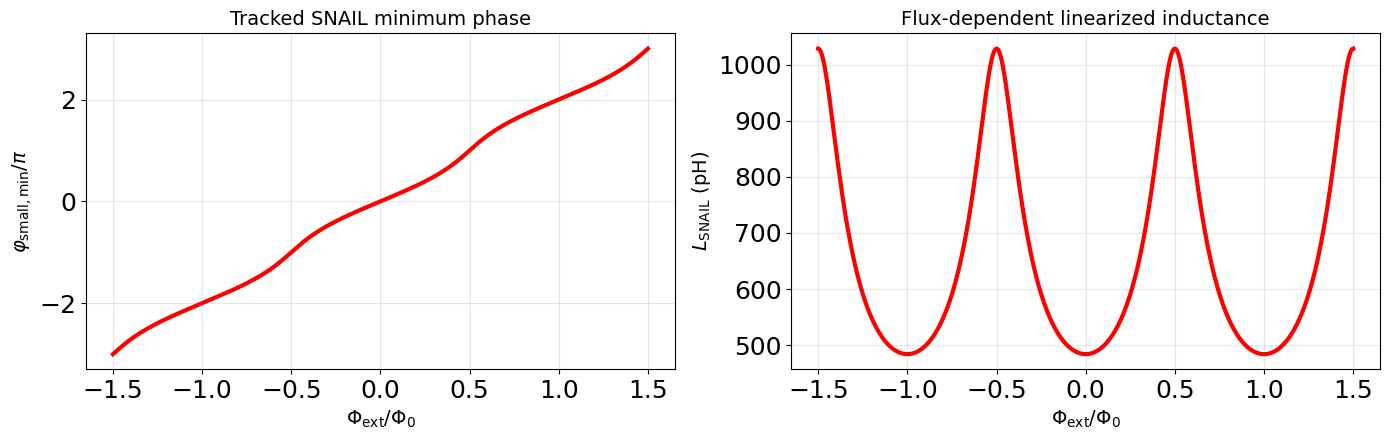

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(flux_frustration, phi_small_min / np.pi, 'r', lw=3)
axes[0].set_xlabel(r'$\Phi_\mathrm{ext}/\Phi_0$', fontsize=14)
axes[0].set_ylabel(r'$\varphi_\mathrm{small,min}/\pi$', fontsize=14)
axes[0].set_title("Tracked SNAIL minimum phase", fontsize=14)
axes[0].grid(alpha=0.3)

axes[1].plot(flux_frustration, L_snail_eff * 1e12, 'r', lw=3)
axes[1].set_xlabel(r'$\Phi_\mathrm{ext}/\Phi_0$', fontsize=14)
axes[1].set_ylabel(r'$L_\mathrm{SNAIL}$ (pH)', fontsize=14)
axes[1].set_title("Flux-dependent linearized inductance", fontsize=14)
axes[1].grid(alpha=0.3)

axes[0].tick_params(axis='y', labelsize=18)
axes[0].tick_params(axis='x', labelsize=18)
axes[1].tick_params(axis='y', labelsize=18)
axes[1].tick_params(axis='x', labelsize=18)
#axes.axis('tight')

plt.tight_layout()
plt.show()

# Plot the S21 map

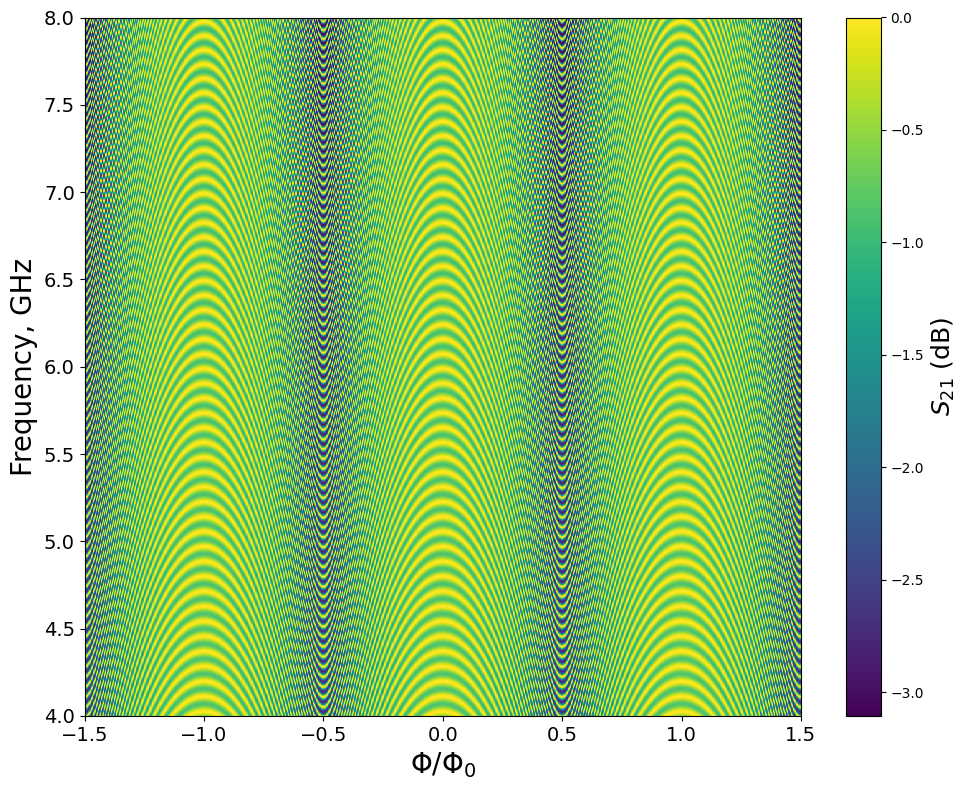

In [40]:
plt.figure(figsize=(10, 8))

mesh = plt.pcolormesh(
    flux_frustration,
    freq_array / 1e9,
    S21_dB,
    shading='auto',
    cmap='viridis'
)

cbar = plt.colorbar(mesh)
cbar.set_label(r'$S_{21}$ (dB)', fontsize=18)

plt.xlabel(r'$\Phi/\Phi_0$', fontsize=20)
plt.ylabel('Frequency, GHz', fontsize=20)
plt.xlim(flux_frustration[0], flux_frustration[-1])
plt.ylim(freq_array[0] / 1e9, freq_array[-1] / 1e9)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()